# 5 · Recovering the hair-cell layer

**What you will do:** get back the stage of the inner-ear model that sits *above* the spikes this dataset ships.

**What you should take away:** this is a real inverse problem with a real identifiability limit, and it opens a comparison — does the bushy-cell layer represent the digits better than the hair-cell layer it came from, or does it throw information away?

Runtime: three to four minutes.

---

## Why this is possible

SHD ships only the last stage of the [LAUSCHER](https://github.com/electronicvisions/lauscher) chain:

```
audio -> basilar membrane -> hair cell -> bushy cell -> SHD
                             (Meddis)     (LIF, 40 afferents)
                             continuous   spikes
                             probability
```

Two facts from the source do the work:

1. The hair-cell stage emits a **firing probability**, not spikes.
2. Hair-cell and bushy-cell channels are **one-to-one** — the 40 afferents are stochastic draws *within* a channel, not a fan-in across channels.

So this is not a blind deconvolution. It is a per-channel problem with a fixed, monotone, saturating forward map: measure that map, then invert it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from compbio2026 import data, lauscher, plotting

plotting.apply_style()
rng = np.random.default_rng(2026)

print("bushy-cell parameters (from the LAUSCHER source):")
for k, v in lauscher.BC_DEFAULTS.items():
    print(f"   {k:<15} {v}")

bushy-cell parameters (from the LAUSCHER source):
   n_convergence   40
   tau_mem         0.001
   tau_syn         0.0005
   tau_refrac      0.001
   weight          13000.0


## Step 1 — measure the forward map

Drive the re-implemented bushy cell with constant probabilities and record the firing rate.

maximum rate reached  883 spikes/s
refractory ceiling    1000 spikes/s


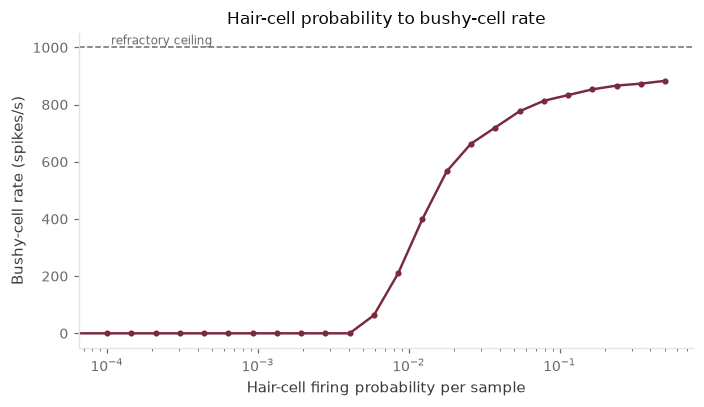

In [2]:
curve = lauscher.transfer_curve(duration=0.15, n_repeats=2)
probs, rates = curve

fig, ax = plt.subplots(figsize=(6.5, 3.8))
plotting.transfer_curve(probs, rates, ax=ax)
ax.set_title("Hair-cell probability to bushy-cell rate")
fig.tight_layout()
plotting.savefig(fig, "05_transfer_curve", outdir="../plots")

print(f"maximum rate reached  {rates.max():.0f} spikes/s")
print(f"refractory ceiling    {1 / lauscher.BC_DEFAULTS['tau_refrac']:.0f} spikes/s")

The curve is monotone — which is what makes it invertible — and it **saturates**. Above the knee, very different probabilities map to nearly the same rate, so the inversion there is ill-posed. Those samples are *censored*, not confidently high.

## Step 2 — validate where you know the answer

Do this before touching SHD. Pick a smooth `p(t)`, simulate a bushy cell from it, then recover `p` from the spikes.

In [3]:
fs = 20_000.0
duration = 0.4
n = int(fs * duration)
tt = np.arange(n) / fs

p_true = 0.03 * (1 + np.sin(2 * np.pi * 8 * tt)) * np.exp(-((tt - 0.2) ** 2) / 0.01)

bc = lauscher.BushyCell(**lauscher.BC_DEFAULTS)
spikes = bc.simulate(p_true, fs, seed=0)
print(f"{spikes.sum():.0f} spikes in {duration:g} s  ->  {spikes.sum() / duration:.0f} spikes/s mean")

106 spikes in 0.4 s  ->  265 spikes/s mean


correlation with truth  r = 0.987
fraction censored       0.000


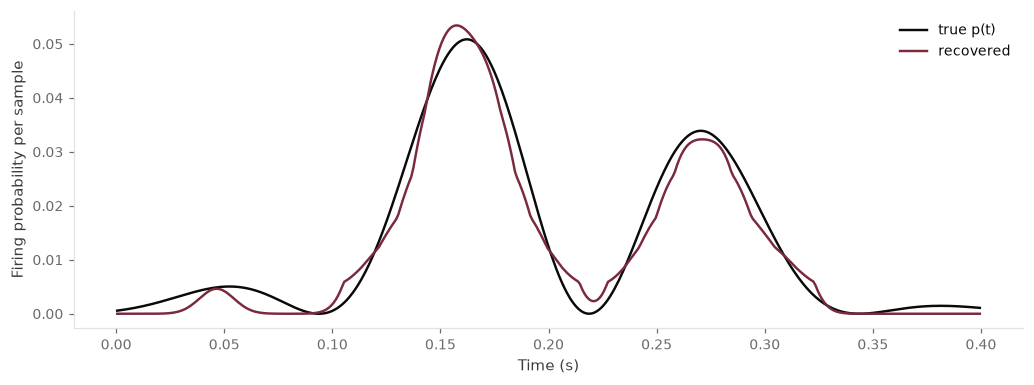

In [4]:
bin_ms = 1.0
step = int(fs * bin_ms / 1e3)
n_use = (n // step) * step
binned = spikes[:n_use].reshape(1, 1, -1, step).sum(axis=-1)
p_true_binned = p_true[:n_use].reshape(-1, step).mean(axis=1)
t_bin = (np.arange(binned.shape[-1]) + 0.5) * bin_ms / 1e3

p_hat, valid = lauscher.estimate_hair_cell_rate(binned, bin_ms=bin_ms, curve=curve, smooth_ms=8.0)

fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.plot(t_bin, p_true_binned, color=plotting.INK, lw=1.6, label="true p(t)")
ax.plot(t_bin, p_hat[0, 0], color=plotting.ACCENT, lw=1.6, label="recovered")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Firing probability per sample")
ax.legend()
fig.tight_layout()
plotting.savefig(fig, "05_recovery_validation", outdir="../plots")

print(f"correlation with truth  r = {np.corrcoef(p_true_binned, p_hat[0, 0])[0, 1]:.3f}")
print(f"fraction censored       {(~valid).mean():.3f}")

**Report both numbers.** The correlation says how well the method works; the censored fraction says how much of the signal it could not see. A high correlation over 5 % of the samples is not the same claim as a high correlation over 95 %.

## Step 3 — the smoothing kernel *is* your time resolution

There is no correct value. There is a trade-off, and you have to state which side of it you chose.

In [5]:
print(f"{'smooth (ms)':>12}   {'r':>6}")
for s in [2.0, 5.0, 10.0, 20.0, 40.0]:
    ph, _ = lauscher.estimate_hair_cell_rate(binned, bin_ms=bin_ms, curve=curve, smooth_ms=s)
    print(f"{s:>12.0f}   {np.corrcoef(p_true_binned, ph[0, 0])[0, 1]:>6.3f}")

 smooth (ms)        r
           2    0.956
           5    0.989
          10    0.982
          20    0.946
          40    0.738


## Step 4 — apply it to SHD

Single trials are sparse: 40 Bernoulli draws per timestep average out a lot, but one utterance does not carry enough spikes to invert finely. **Average over trials of the same digit first** — then the estimate is a statement about the class rather than the utterance.

In [6]:
shd = data.load("train")
word = "seven"
trials = np.flatnonzero(shd.labels == data.DIGIT_KEYS.index(word))[:80]

X, _, _ = data.build_design_matrix(shd, bin_ms=2.0, t_max_ms=800.0, trials=trials)
X_mean = X.mean(axis=0, keepdims=True)

p_hat_shd, valid_shd = lauscher.estimate_hair_cell_rate(X_mean, bin_ms=2.0, curve=curve, smooth_ms=6.0)
print(f"averaged {len(trials)} trials of \"{word}\"")
print(f"censored fraction: {(~valid_shd).mean():.4f}")

averaged 80 trials of "seven"
censored fraction: 0.0000


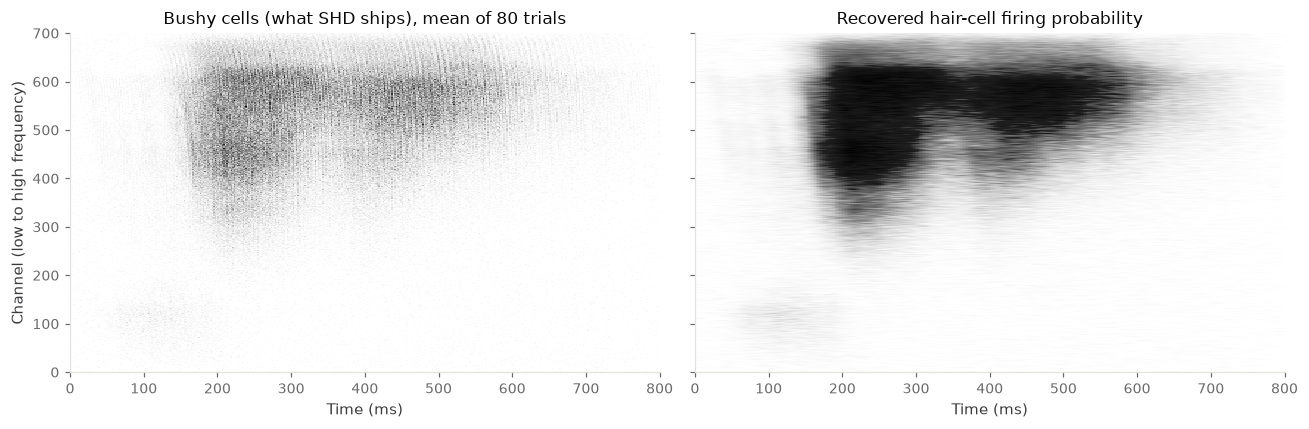

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].imshow(X_mean[0], aspect="auto", origin="lower", cmap="Greys",
               extent=[0, 800, 0, X.shape[1]], interpolation="nearest")
axes[0].set_title(f'Bushy cells (what SHD ships), mean of {len(trials)} trials')
axes[1].imshow(p_hat_shd[0], aspect="auto", origin="lower", cmap="Greys",
               extent=[0, 800, 0, X.shape[1]], interpolation="nearest")
axes[1].set_title("Recovered hair-cell firing probability")
for ax in axes:
    ax.set_xlabel("Time (ms)")
axes[0].set_ylabel("Channel (low to high frequency)")
fig.tight_layout()
plotting.savefig(fig, "05_hair_cell_layer", outdir="../plots")

## Step 5 — what this is for

You now have two representations of the same stimulus, one stage apart. Run the whole notebook 2-to-4 analysis on both and compare:

- Does the bushy-cell layer separate the digits **better** than the hair-cell layer it came from?
- Or does coincidence detection **discard** information a decoder could have used?

That is a genuinely open question, answerable with the tools already in this repository, and a complete project on its own.

In [8]:
# Sketch. Match the readout AND the dimensionality across layers, or the
# comparison is about feature count rather than about the representation.
#
# from compbio2026 import decoding
# sub = rng.choice(np.flatnonzero(shd.english_mask()), size=800, replace=False)
# X_bc, y_sub, _ = data.build_design_matrix(shd, bin_ms=2.0, t_max_ms=800.0, trials=sub)
# p_hc, _ = lauscher.estimate_hair_cell_rate(X_bc, bin_ms=2.0, curve=curve, smooth_ms=6.0)
# print("bushy cell:", decoding.decode(data.flatten(X_bc), y_sub)["mean"])
# print("hair cell :", decoding.decode(data.flatten(p_hc), y_sub)["mean"])

---

## What this method cannot do

State all of it in your report — the limits are the interesting part.

- **The refractory period censors the top of the range.** A bushy cell cannot exceed ~1000 spikes/s, so the transfer curve saturates and high probabilities are not identifiable.
- **You recover an output, not a state.** The Meddis model has internal variables (transmitter available, in the cleft, being reprocessed) that a firing rate does not pin down.
- **Smoothing sets the time resolution.** The bushy-cell stage exists partly to sharpen phase locking; smoothing throws that away. Any claim about fine temporal structure is a claim about your kernel.
- **Well-posedness depends on the 1:1 channel mapping.** Change `n_convergence`, or model convergence *across* channels, and the guarantee goes away.

## Exercises

1. **Close the loop against ground truth.** `lauscher.run_lauscher("something.wav")` runs the real chain and returns every stage. Compare the true firing probability against your estimate from the bushy-cell spikes of the same run.
2. **Map the censored region.** Where in SHD does saturation occur — particular channels, particular times? Does it change what you can claim?
3. **Convergence sensitivity.** Re-measure the transfer curve with `n_convergence` in {10, 40, 100}. How much does the recovery depend on knowing the right value?
4. **Complete the layer comparison** in the sketch above, with matched readouts and matched dimensionality.